In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data processing

In [90]:
df = pd.read_csv('vgsales_top300.csv')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          300 non-null    int64  
 1   Name          300 non-null    object 
 2   Platform      300 non-null    object 
 3   Year          300 non-null    int64  
 4   Genre         300 non-null    object 
 5   Publisher     300 non-null    object 
 6   NA_Sales      300 non-null    float64
 7   EU_Sales      300 non-null    float64
 8   JP_Sales      300 non-null    float64
 9   Other_Sales   300 non-null    float64
 10  Global_Sales  300 non-null    float64
dtypes: float64(5), int64(2), object(4)
memory usage: 25.9+ KB


In [92]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,2004.900000,4.008133,2.471300,1.087733,0.776567,8.343333
std,86.746758,7.535202,4.090170,2.475031,1.540248,1.020944,7.282351
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,4.010000
25%,75.750000,2000.750000,2.172500,1.240000,0.060000,0.287500,4.695000
50%,150.500000,2007.000000,2.980000,1.930000,0.295000,0.570000,5.835000
75%,225.250000,2010.250000,4.280000,2.835000,1.572500,0.890000,8.885000
max,300.000000,2016.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [93]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [94]:
df['Platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN'], dtype=object)

# 2a. Bar Chart

In [95]:
# Counting the number of games of the top seven platforms
df[df['Platform'].isin(['X360', 'PS3', 'PS2', 'Wii', 'PS', 'DS', 'PS4'])].shape[0]

206

In [96]:
# Calculating percentage
total_games = len(df)

percentage = (206 / total_games) * 100

percentage

68.66666666666667

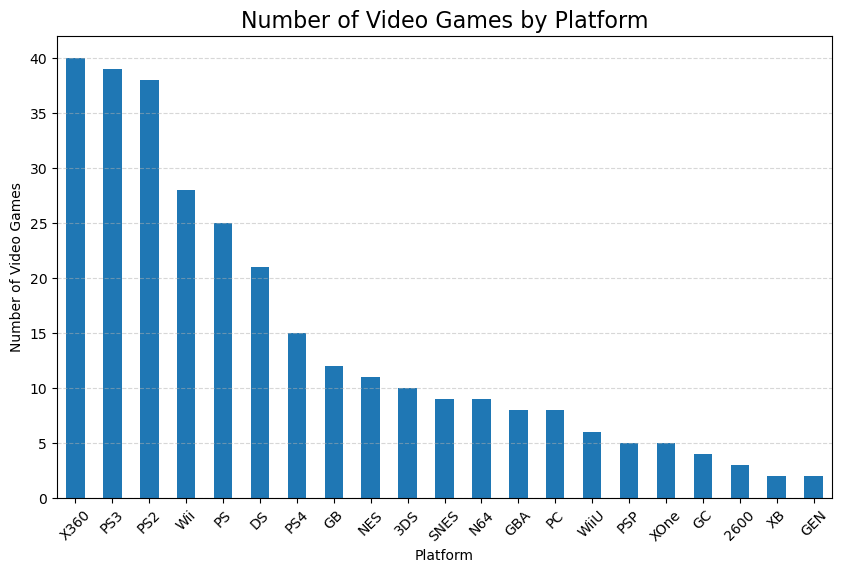

In [97]:
platform_counts = df['Platform'].value_counts()

plt.figure(figsize=(10, 6))  
platform_counts.plot(kind='bar') 
plt.title('Number of Video Games by Platform', fontsize=16)  
plt.xlabel('Platform')  
plt.xticks(rotation=45) 
plt.ylabel('Number of Video Games')  
plt.grid(axis='y', linestyle='--', alpha=0.5)  
plt.show() 

^^ This bar chart visualizes the number of video games by gaming platform. It shows us that seven gaming platforms 
dominate the market, owning 68.7% of the total amount of video games.

# 2b. Histogram

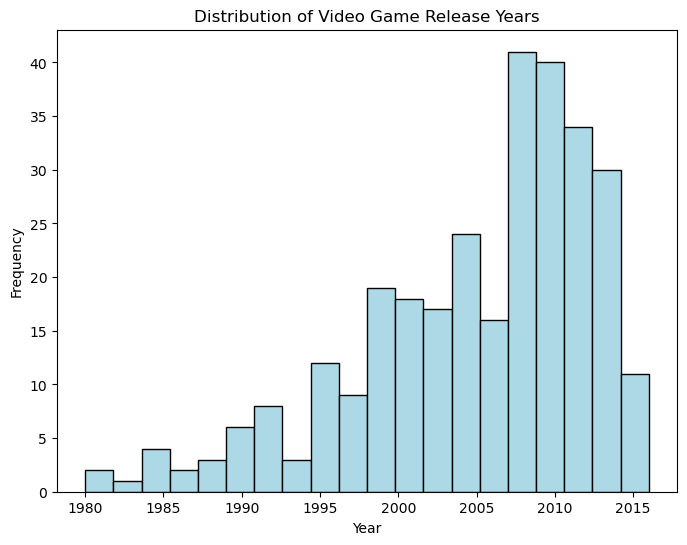

In [98]:
plt.figure(figsize=(8, 6)) 
plt.hist(df['Year'].dropna(), bins=20, color='lightblue', edgecolor='black')
plt.title('Distribution of Video Game Release Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

^^ This histogram visualizes the distribution of video games released each year. We can see that the majority of video games were released around the years of 1998-2014, with the highest number of video game releases per year being from around 2008-2013. It visualizes the concentration of data very well.

# 2c. Pie Chart

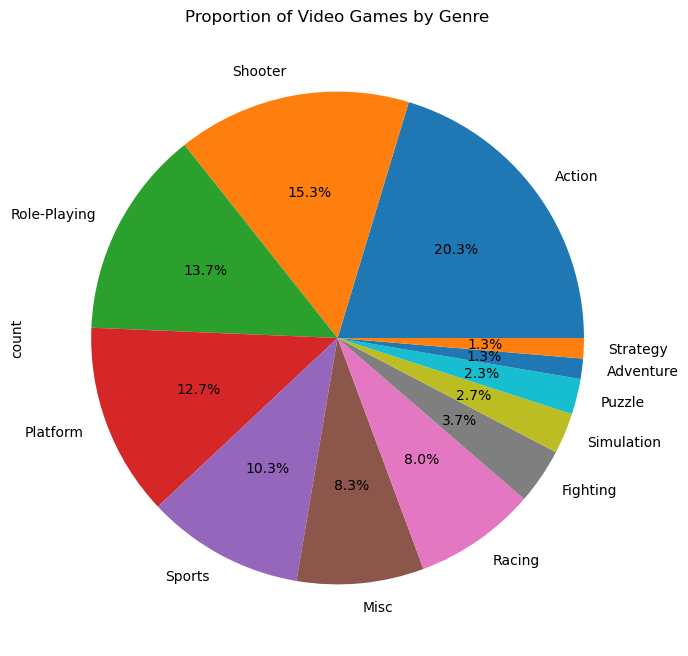

In [99]:
genre_counts = df['Genre'].value_counts()

plt.figure(figsize=(8,8))
genre_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Video Games by Genre')
plt.show()

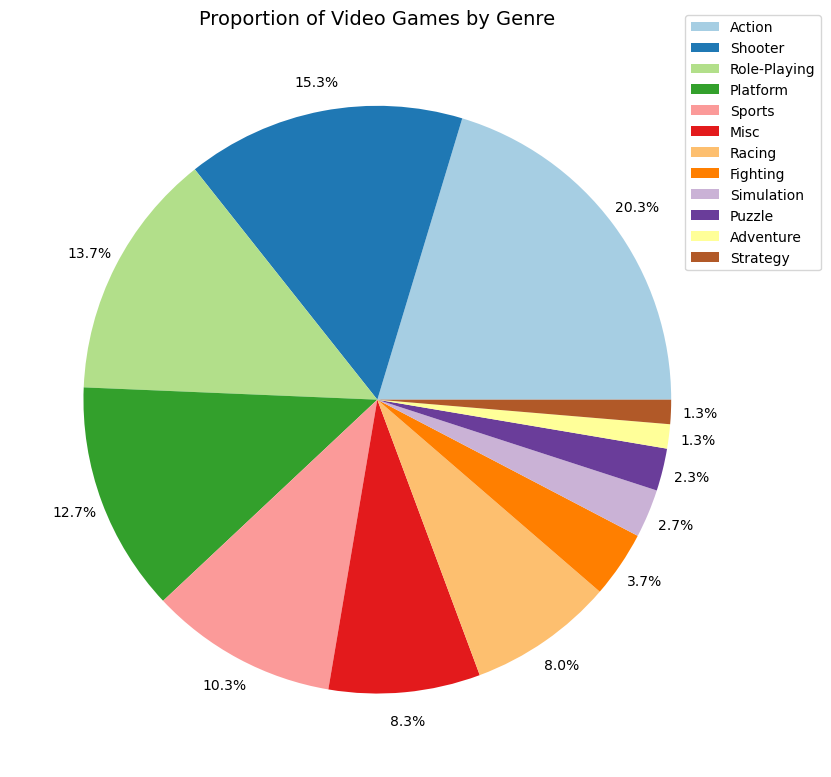

In [100]:
labels = genre_counts.index

plt.figure(figsize=(12,8))  

genre_counts.plot(kind='pie',
                  autopct='%1.1f%%',
                  colors=plt.cm.Paired.colors,
                  labels=None,
                  pctdistance=1.1,
                 )

plt.legend(labels, loc='center left', bbox_to_anchor=(0.91, 0.85))

plt.title('Proportion of Video Games by Genre', fontsize=14)
plt.ylabel('')

plt.tight_layout()
plt.show()

^^ These two pie charts represent the proportion of video games by genre. As we can see, the top four most popular
genres are Action, Shooter, Role-Playing, and Platform, making up approximately two-thirds of the data.

# 2d. Line Chart

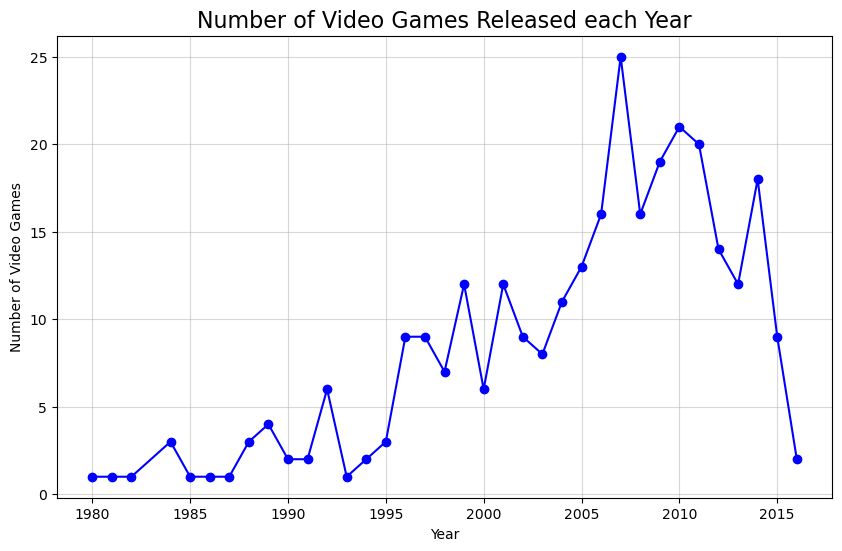

In [101]:
games_by_year = df.groupby('Year')['Year'].count()

plt.figure(figsize=(10, 6))  
games_by_year.plot(kind='line', marker='o', color='blue')
plt.title('Number of Video Games Released each Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Video Games')
plt.grid(True, alpha=0.5)
plt.show()

^^ This line chart visualizes the number of video games released per year. It shows the change in video games released each year very well, as with line charts we can see the dramatic ups and downs of the data; the data trends. 

# 2e. Area Chart

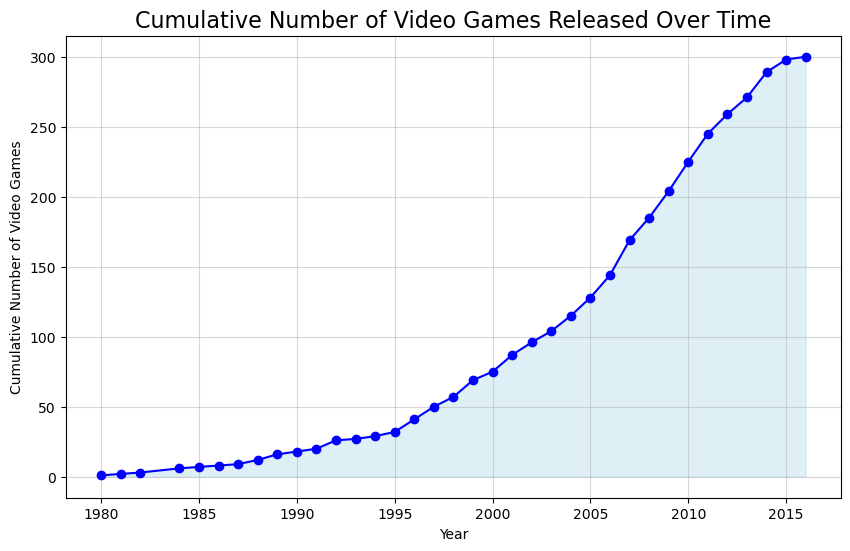

In [102]:
games_by_year = df.groupby('Year')['Year'].count()

cumulative_games = games_by_year.cumsum()

plt.figure(figsize=(10, 6))
plt.fill_between(cumulative_games.index, cumulative_games, color='lightblue', alpha=0.4)
plt.plot(cumulative_games.index, cumulative_games, color='blue', marker='o')

plt.title('Cumulative Number of Video Games Released Over Time', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Cumulative Number of Video Games')
plt.grid(True, alpha=0.5)
plt.show()

^^ This area chart visualizes the cumulative number of video games released over time. It shows the 
exponential increase in sales starting in the late 90s and increasing even more dramatically starting around 2005.

# 2f. Scatter Plot

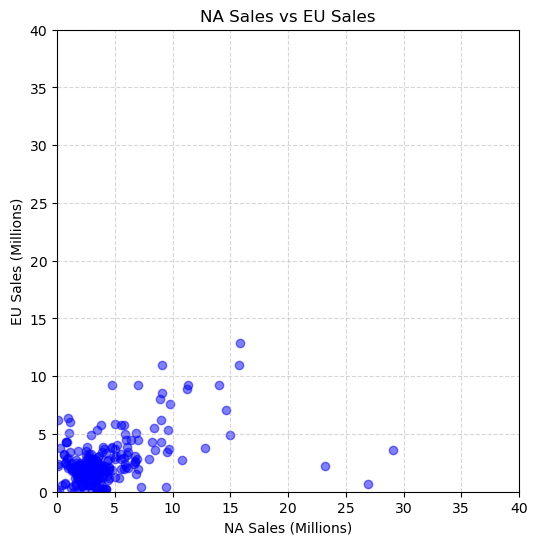

In [103]:
plt.figure(figsize=(8, 6))

plt.scatter(df['NA_Sales'], df['EU_Sales'], color='blue', alpha=0.5)

plt.xlim(0, 40)
plt.ylim(0, 40)
plt.gca().set_aspect('equal', adjustable='box')

plt.title('NA Sales vs EU Sales')
plt.xlabel('NA Sales (Millions)')
plt.ylabel('EU Sales (Millions)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

^^ This scatter plot represents the sales each game had in the NA market versus in the EU market. This scatter plot is especially interesting because it compares the two largest video game markets, according to this dataset.

Each dot represents one video game.